# 03 — DREAMER Data Exploration
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Explore the DREAMER dataset before preprocessing. DREAMER provides EEG (14 channels, 128 Hz)
and ECG (2 channels, 256 Hz) from 23 participants during affect elicitation via film clips,
with self-reported valence, arousal, dominance ratings (scale 1–5).

## Role in This Research
- Binary arousal classification: high arousal (>3) = stress-proxy, low arousal (<=3) = calm
- EEG frontal asymmetry features (DASM, RASM at F3/F4) for valence discrimination
- Cross-dataset generalization (train WESAD → test DREAMER and reverse)

## EEG Channel Layout (Emotiv EPOC)
```
AF3  F7  F3  FC5  T7  P7  O1  O2  P8  T8  FC6  F4  F8  AF4
```
Frontal channels: **F3** (index 2) and **F4** (index 11)

---
> Set `DREAMER_PATH` in Section 0 before running.


## 0. Configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from datetime import datetime
from scipy.io import loadmat
from scipy import signal as scipy_signal

warnings.filterwarnings('ignore')

# ── SET THIS ──────────────────────────────────────────────────────────────────
DREAMER_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat"
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '03_dreamer_exploration')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

N_SUBJECTS  = 23
N_VIDEOS    = 18
FS_EEG      = 128
FS_ECG      = 256
N_EEG_CH    = 14
N_ECG_CH    = 2

EEG_CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
F3_IDX = 2
F4_IDX = 11

BANDS = {
    'delta': (1,   4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta' : (13, 30),
    'gamma': (30, 45)
}

AROUSAL_THRESHOLD = 3  # >3 = high arousal (stress-proxy), <=3 = low (calm)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  DREAMER path : {DREAMER_PATH}')
print(f'  EEG channels : {EEG_CHANNELS}')
print(f'  F3 idx={F3_IDX} ({EEG_CHANNELS[F3_IDX]})  F4 idx={F4_IDX} ({EEG_CHANNELS[F4_IDX]})')
print(f'  Plots        : {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  DREAMER path : C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat
  EEG channels : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
  F3 idx=2 (F3)  F4 idx=11 (F4)
  Plots        : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\03_dreamer_exploration


## 1. Load the .mat File

In [2]:
print('Loading DREAMER.mat — may take 30-60 seconds...')
mat     = loadmat(DREAMER_PATH, simplify_cells=True)
dreamer = mat['DREAMER']
data_all = dreamer['Data']
print(f'Loaded. Subjects found: {len(data_all)}')
print(f'DREAMER fields : {list(dreamer.keys())}')
print(f'Subject 0 keys : {list(data_all[0].keys())}')


Loading DREAMER.mat — may take 30-60 seconds...
Loaded. Subjects found: 23
DREAMER fields : ['Data', 'EEG_SamplingRate', 'ECG_SamplingRate', 'EEG_Electrodes', 'noOfSubjects', 'noOfVideoSequences', 'Disclaimer', 'Provider', 'Version', 'Acknowledgement']
Subject 0 keys : ['Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance']


## 2. Inspect Data Structure

In [3]:
s0 = data_all[0]

# EEG
eeg_data     = s0['EEG']
eeg_stimuli  = eeg_data['stimuli']
eeg_baseline = eeg_data['baseline']
print('=== EEG ===')
print(f'  EEG keys        : {list(eeg_data.keys())}')
print(f'  Number of videos: {len(eeg_stimuli)}')
stim0 = np.array(eeg_stimuli[0])
if stim0.shape[0] < stim0.shape[1]:
    stim0 = stim0.T
print(f'  Stimulus 0 shape: {stim0.shape}  ({stim0.shape[0]/FS_EEG:.1f}s x {stim0.shape[1]} ch)')
base0 = np.array(eeg_baseline)
if base0.ndim > 1 and base0.shape[0] < base0.shape[1]:
    base0 = base0.T
print(f'  Baseline shape  : {base0.shape}')

# ECG
ecg_data    = s0['ECG']
ecg_stimuli = ecg_data['stimuli']
print('\n=== ECG ===')
print(f'  ECG keys        : {list(ecg_data.keys())}')
print(f'  Number of videos: {len(ecg_stimuli)}')
ecg0 = np.array(ecg_stimuli[0])
print(f'  Stimulus 0 shape: {ecg0.shape}')

# Ratings
print('\n=== RATINGS ===')
for r in ['Valence', 'Arousal', 'Dominance']:
    if r in s0:
        v = np.array(s0[r]).flatten()
        print(f'  {r}: shape={v.shape}  min={v.min():.1f}  max={v.max():.1f}  mean={v.mean():.2f}')
    else:
        print(f'  {r}: not found at top level — checking subject keys: {list(s0.keys())}')


=== EEG ===
  EEG keys        : ['baseline', 'stimuli']
  Number of videos: 18
  Stimulus 0 shape: (25472, 14)  (199.0s x 14 ch)
  Baseline shape  : (18,)

=== ECG ===
  ECG keys        : ['baseline', 'stimuli']
  Number of videos: 18
  Stimulus 0 shape: (50944, 2)

=== RATINGS ===
  Valence: not found at top level — checking subject keys: ['Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance']
  Arousal: not found at top level — checking subject keys: ['Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance']
  Dominance: not found at top level — checking subject keys: ['Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance']


## 3. Extract Ratings Across All Subjects

In [4]:
def get_ratings(subject_data):
    def find_key(d, candidates):
        for c in candidates:
            if c in d:
                return np.array(d[c]).flatten()
        return np.full(N_VIDEOS, np.nan)
    val = find_key(subject_data, ['Valence','valence','val'])
    aro = find_key(subject_data, ['Arousal','arousal','aro'])
    dom = find_key(subject_data, ['Dominance','dominance','dom'])
    return val, aro, dom

rows = []
for sid in range(N_SUBJECTS):
    val, aro, dom = get_ratings(data_all[sid])
    for vid in range(N_VIDEOS):
        rows.append({
            'subject_id'     : sid + 1,
            'video_id'       : vid + 1,
            'valence'        : val[vid] if vid < len(val) else np.nan,
            'arousal'        : aro[vid] if vid < len(aro) else np.nan,
            'dominance'      : dom[vid] if vid < len(dom) else np.nan,
        })

df_ratings = pd.DataFrame(rows)
df_ratings['arousal_binary'] = (df_ratings['arousal'] > AROUSAL_THRESHOLD).astype(int)
df_ratings['valence_binary'] = (df_ratings['valence'] > AROUSAL_THRESHOLD).astype(int)

print(f'Total recordings : {len(df_ratings)} ({N_SUBJECTS} subjects x {N_VIDEOS} videos)')
print('\n=== RATING STATISTICS ===')
print(df_ratings[['valence','arousal','dominance']].describe().round(2))
print('\n=== AROUSAL BINARIZATION ===')
for k, v in sorted(df_ratings['arousal_binary'].value_counts().items()):
    name = 'high arousal (stress-proxy)' if k==1 else 'low arousal (calm)'
    print(f'  {k} ({name}): {v} ({100*v/len(df_ratings):.1f}%)')

p = os.path.join(OUTPUT_DATA_DIR, 'dreamer_ratings.csv')
df_ratings.to_csv(p, index=False)
print(f'\nSaved: {p}')


Total recordings : 414 (23 subjects x 18 videos)

=== RATING STATISTICS ===
       valence  arousal  dominance
count      0.0      0.0        0.0
mean       NaN      NaN        NaN
std        NaN      NaN        NaN
min        NaN      NaN        NaN
25%        NaN      NaN        NaN
50%        NaN      NaN        NaN
75%        NaN      NaN        NaN
max        NaN      NaN        NaN

=== AROUSAL BINARIZATION ===
  0 (low arousal (calm)): 414 (100.0%)

Saved: ..\results\output_data\dreamer_ratings.csv


## 4. Ratings Distribution Plots

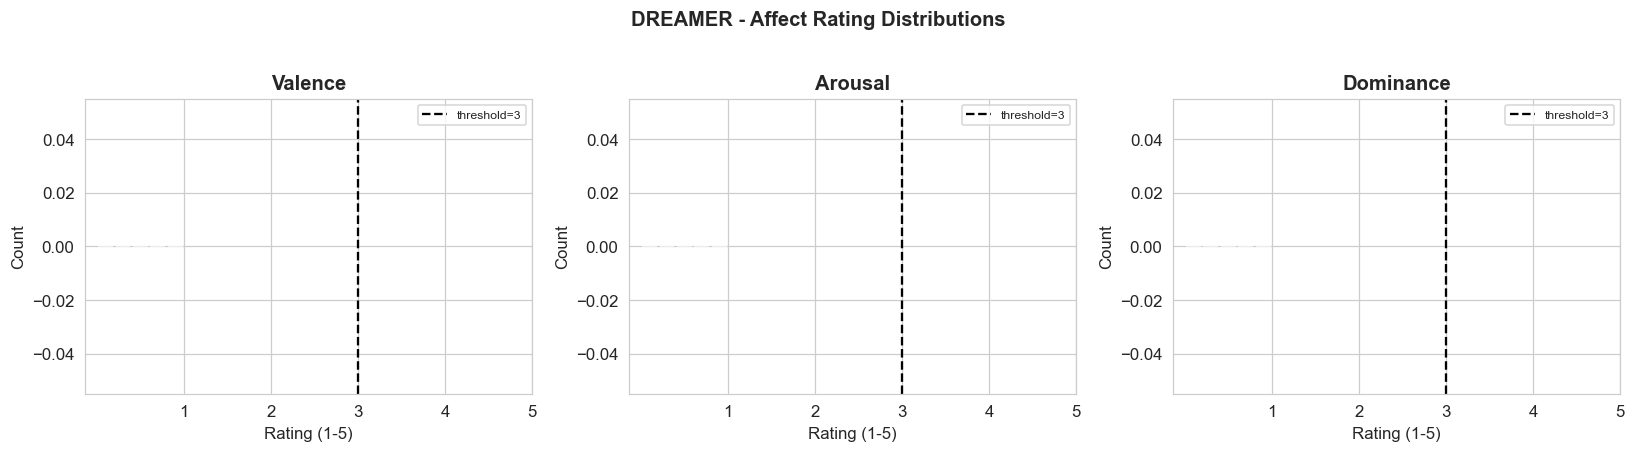

Saved: ..\results\plots\03_dreamer_exploration\rating_distributions.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['valence','arousal','dominance'],
                           ['#2196F3','#F44336','#FF9800']):
    ax.hist(df_ratings[col].dropna(), bins=5, color=color,
            alpha=0.8, edgecolor='white', rwidth=0.85)
    ax.axvline(AROUSAL_THRESHOLD, color='black', linestyle='--',
               lw=1.5, label=f'threshold={AROUSAL_THRESHOLD}')
    ax.set_title(col.capitalize(), fontweight='bold')
    ax.set_xlabel('Rating (1-5)')
    ax.set_ylabel('Count')
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=8)
plt.suptitle('DREAMER - Affect Rating Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'rating_distributions.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


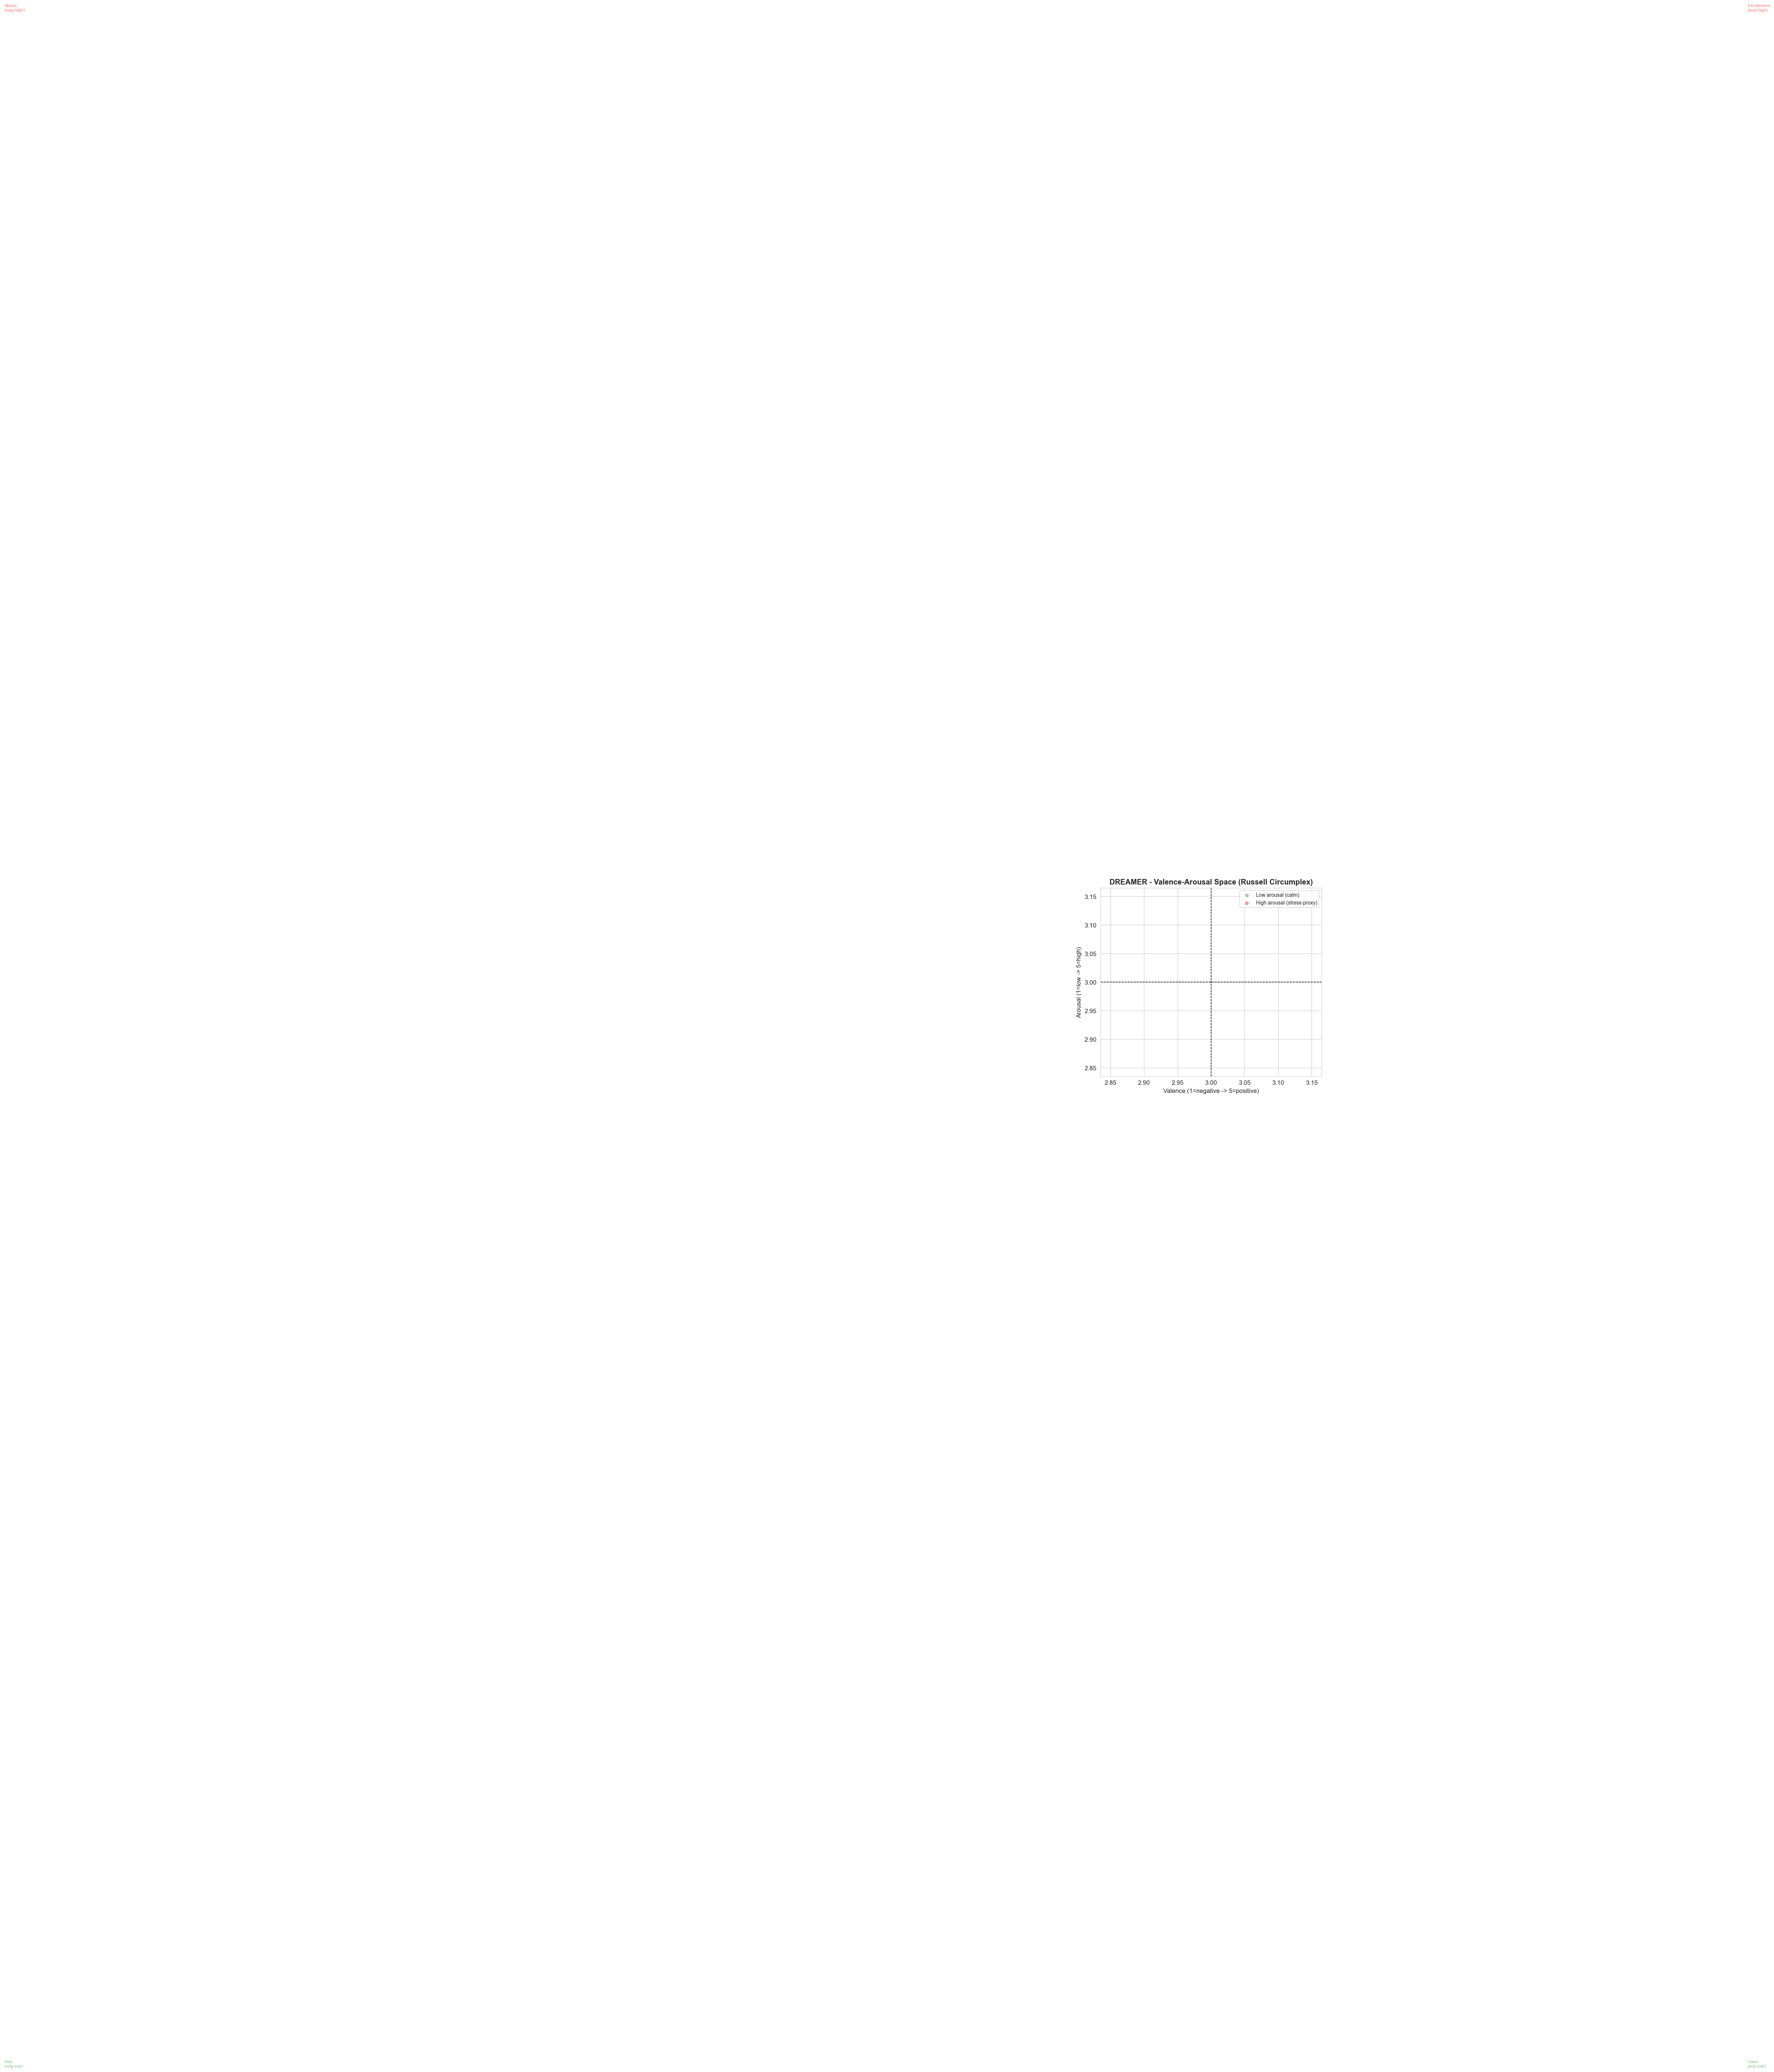

Saved: ..\results\plots\03_dreamer_exploration\valence_arousal_circumplex.png
NOTE: High-arousal positive states (top-right) are grouped with stress-proxy.
EEG frontal asymmetry features (DASM/RASM) are designed to separate them.


In [6]:
# Valence-Arousal scatter (circumplex model)
fig, ax = plt.subplots(figsize=(7, 6))
for bl, color, name in [(0,'#4CAF50','Low arousal (calm)'),
                         (1,'#F44336','High arousal (stress-proxy)')]:
    mask = df_ratings['arousal_binary'] == bl
    ax.scatter(df_ratings.loc[mask,'valence'], df_ratings.loc[mask,'arousal'],
               c=color, alpha=0.5, s=30, label=name)
ax.axhline(AROUSAL_THRESHOLD, color='black', linestyle='--', lw=1)
ax.axvline(AROUSAL_THRESHOLD, color='black', linestyle='--', lw=1)
ax.set_xlabel('Valence (1=negative -> 5=positive)')
ax.set_ylabel('Arousal (1=low -> 5=high)')
ax.set_title('DREAMER - Valence-Arousal Space (Russell Circumplex)', fontweight='bold')
ax.legend(fontsize=9)
ax.text(1.2, 4.7, 'Stress\n(neg,high)', fontsize=8, color='#F44336', alpha=0.7)
ax.text(3.8, 4.7, 'Excitement\n(pos,high)', fontsize=8, color='#F44336', alpha=0.7)
ax.text(1.2, 1.1, 'Sad\n(neg,low)', fontsize=8, color='#4CAF50', alpha=0.7)
ax.text(3.8, 1.1, 'Calm\n(pos,low)', fontsize=8, color='#4CAF50', alpha=0.7)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'valence_arousal_circumplex.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')
print('NOTE: High-arousal positive states (top-right) are grouped with stress-proxy.')
print('EEG frontal asymmetry features (DASM/RASM) are designed to separate them.')


## 5. EEG Signal Inspection

In [7]:
# Shape and per-channel stats
s0_stim = np.array(data_all[0]['EEG']['stimuli'][0])
if s0_stim.shape[0] < s0_stim.shape[1]:
    s0_stim = s0_stim.T
print(f'EEG stimulus shape: {s0_stim.shape}  '
      f'({s0_stim.shape[0]/FS_EEG:.1f}s x {s0_stim.shape[1]} channels)')
print(f'Channels: {EEG_CHANNELS}')
print('\nPer-channel stats (subject 1, video 1):')
for i, ch in enumerate(EEG_CHANNELS):
    tag = ' <- FRONTAL ASYMMETRY' if ch in ['F3','F4'] else ''
    d   = s0_stim[:, i]
    print(f'  {ch:5s}: mean={d.mean():8.3f}  std={d.std():7.3f}{tag}')


EEG stimulus shape: (25472, 14)  (199.0s x 14 channels)
Channels: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

Per-channel stats (subject 1, video 1):
  AF3  : mean=4380.218  std= 10.172
  F7   : mean=4093.074  std= 11.241
  F3   : mean=4158.109  std= 87.594 <- FRONTAL ASYMMETRY
  FC5  : mean=4393.519  std= 92.847
  T7   : mean=4296.000  std=109.926
  P7   : mean=4378.748  std= 55.894
  O1   : mean=4434.145  std= 64.279
  O2   : mean=3955.981  std=107.754
  P8   : mean=4304.093  std= 91.819
  T8   : mean=4256.660  std=112.152
  FC6  : mean=3934.477  std= 72.592
  F4   : mean=4405.790  std= 60.097 <- FRONTAL ASYMMETRY
  F8   : mean=4285.141  std=100.345
  AF4  : mean=4158.345  std=123.644


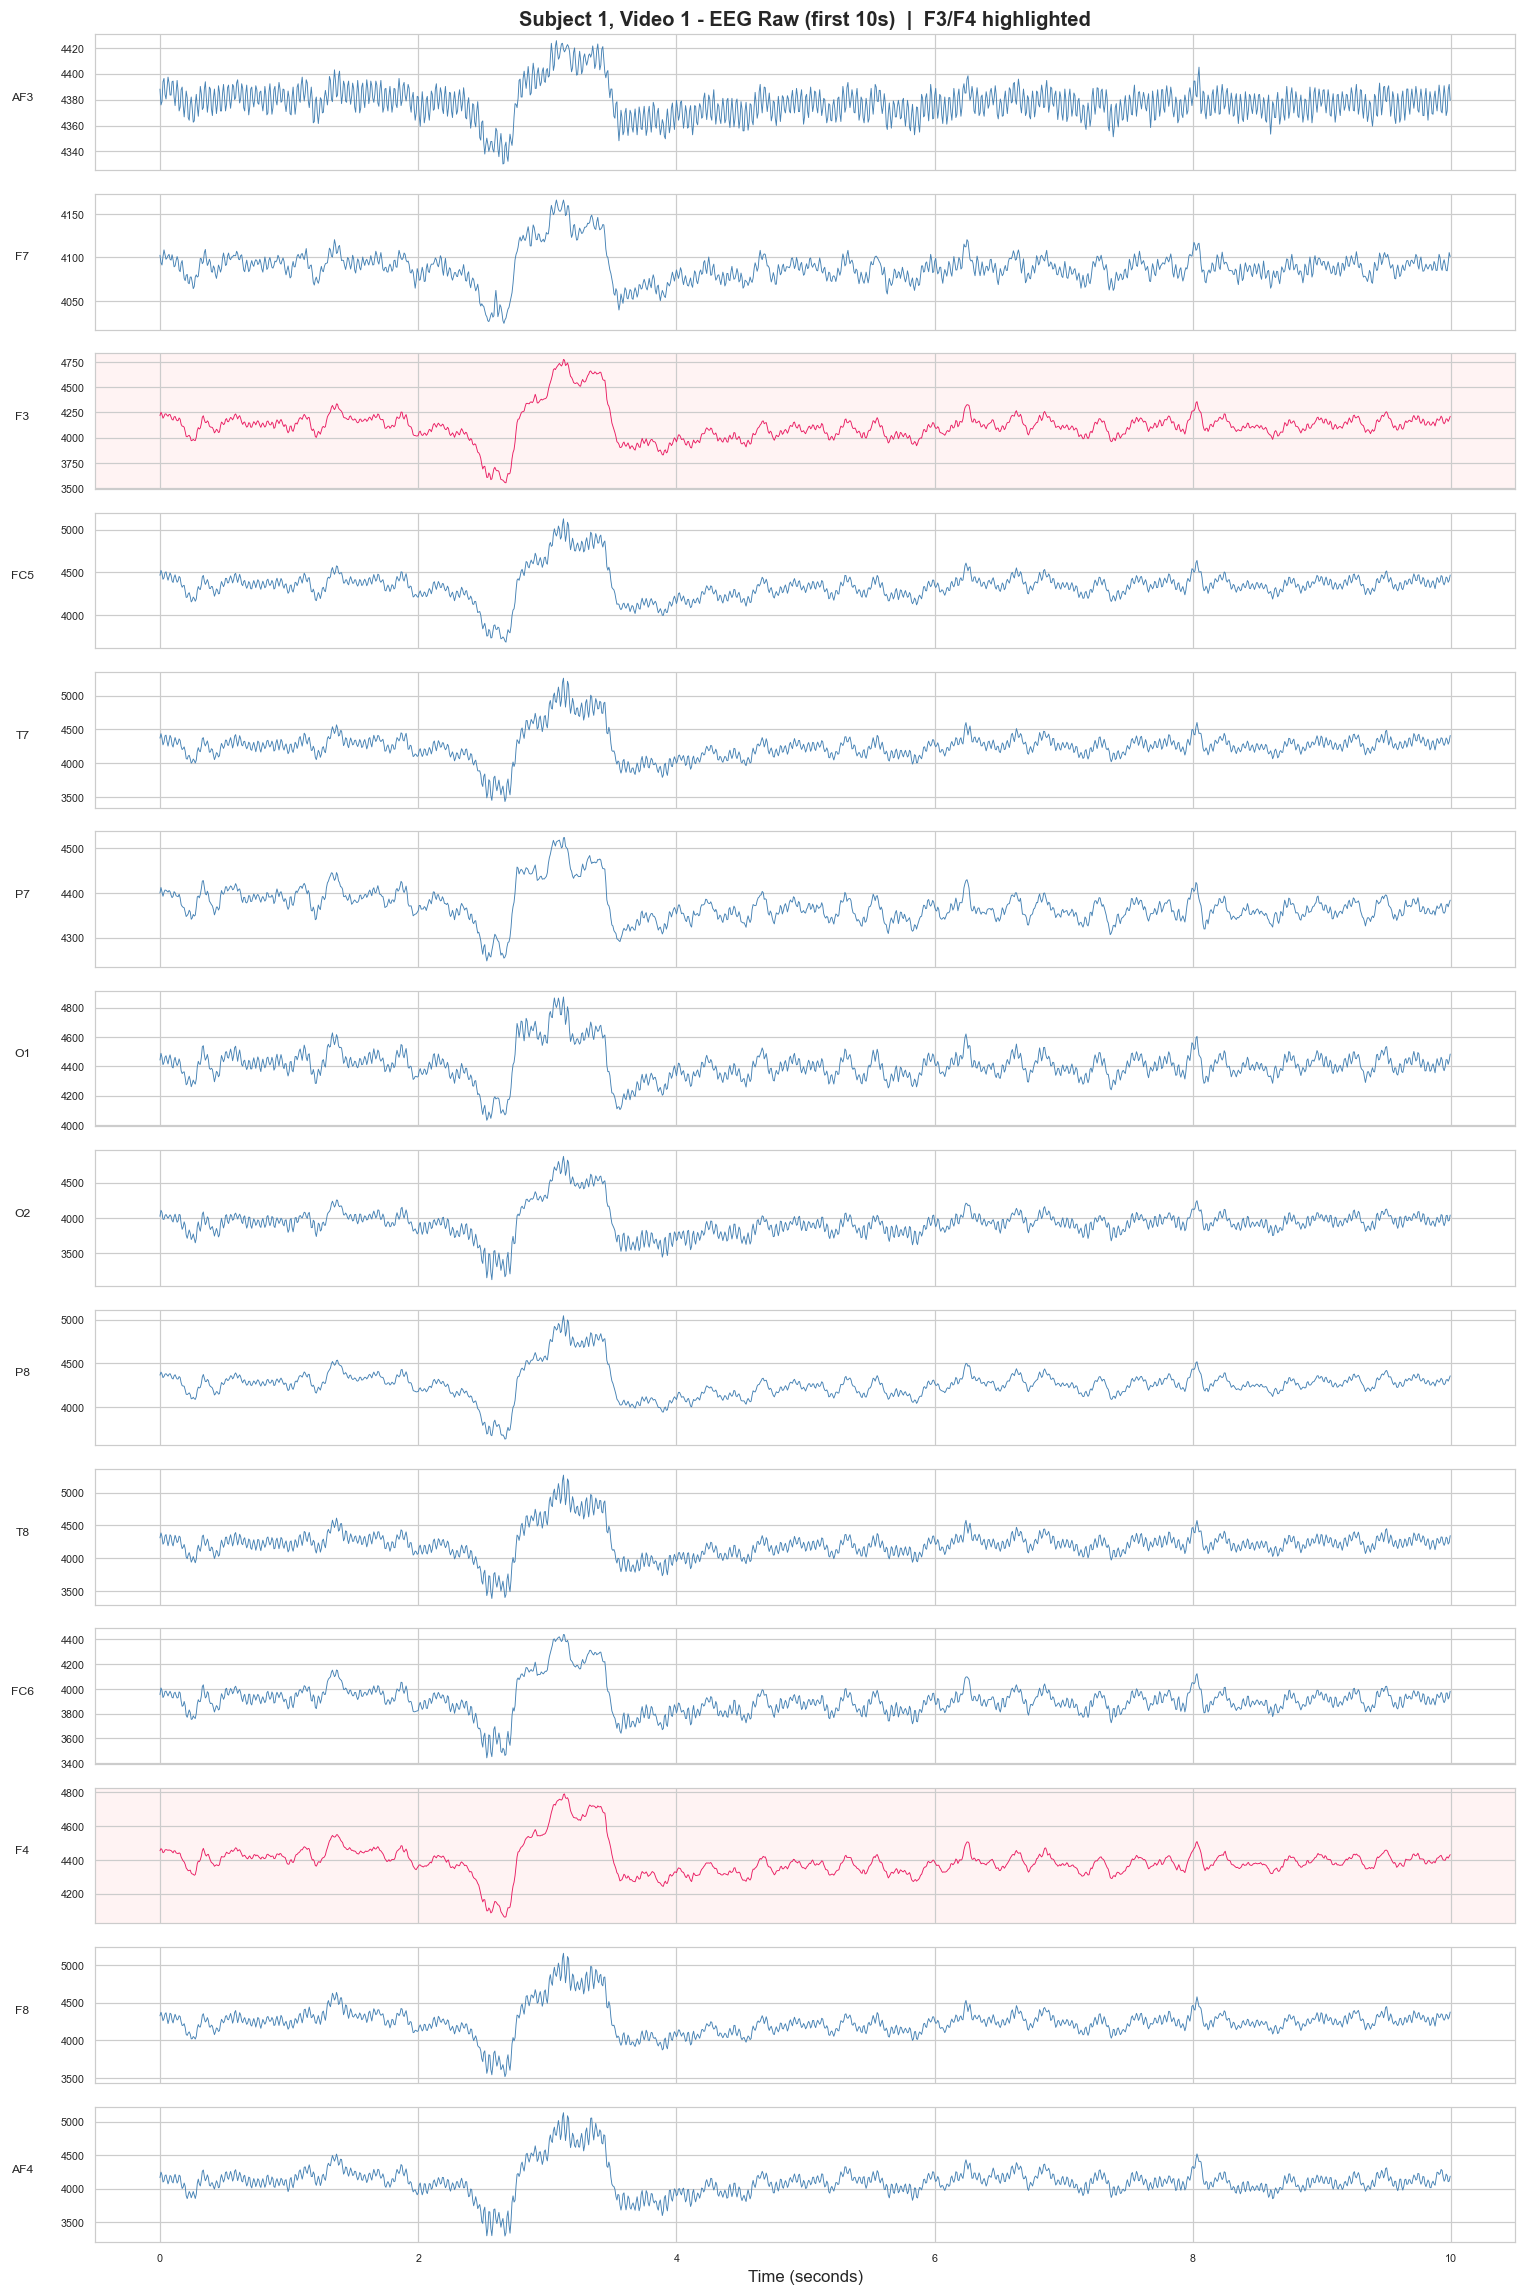

Saved: ..\results\plots\03_dreamer_exploration\S1_eeg_raw_all_channels.png


In [8]:
# Plot all EEG channels — first 10 seconds
n_plot = 10 * FS_EEG
t      = np.arange(n_plot) / FS_EEG
fig, axes = plt.subplots(N_EEG_CH, 1, figsize=(14, 1.5*N_EEG_CH), sharex=True)
for i, (ax, ch) in enumerate(zip(axes, EEG_CHANNELS)):
    color = '#E91E63' if ch in ['F3','F4'] else 'steelblue'
    ax.plot(t, s0_stim[:n_plot, i], lw=0.6, color=color)
    ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=25)
    ax.tick_params(labelsize=7)
    if ch in ['F3','F4']:
        ax.set_facecolor('#FFF3F3')
axes[-1].set_xlabel('Time (seconds)')
axes[0].set_title('Subject 1, Video 1 - EEG Raw (first 10s)  |  F3/F4 highlighted',
                   fontweight='bold')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'S1_eeg_raw_all_channels.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 6. Frontal Asymmetry Preview (DASM / RASM)
Preview of the key valence-discriminating features extracted in notebook 04.

In [9]:
def band_power(sig, fs, fmin, fmax):
    nperseg = min(fs * 2, len(sig))
    freqs, psd = scipy_signal.welch(sig, fs=fs, nperseg=nperseg)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx])

print('Computing alpha-band frontal asymmetry for all subjects/videos...')
alpha_rows = []
for sid in range(N_SUBJECTS):
    s = data_all[sid]
    val, aro, _ = get_ratings(s)
    for vid, stim in enumerate(s['EEG']['stimuli']):
        eeg = np.array(stim)
        if eeg.shape[0] < eeg.shape[1]:
            eeg = eeg.T
        if eeg.shape[1] != N_EEG_CH:
            continue
        f3a = band_power(eeg[:, F3_IDX], FS_EEG, 8, 13)
        f4a = band_power(eeg[:, F4_IDX], FS_EEG, 8, 13)
        aro_v = aro[vid] if vid < len(aro) else np.nan
        val_v = val[vid] if vid < len(val) else np.nan
        alpha_rows.append({
            'subject_id'    : sid + 1,
            'video_id'      : vid + 1,
            'f3_alpha'      : f3a,
            'f4_alpha'      : f4a,
            'dasm'          : f3a - f4a,
            'rasm'          : f4a / (f3a + 1e-10),
            'arousal'       : aro_v,
            'valence'       : val_v,
            'arousal_binary': int(aro_v > AROUSAL_THRESHOLD) if not np.isnan(aro_v) else np.nan,
            'valence_binary': int(val_v > AROUSAL_THRESHOLD) if not np.isnan(val_v) else np.nan,
        })

df_alpha = pd.DataFrame(alpha_rows)
print(f'Done. {len(df_alpha)} recordings processed.')
print(df_alpha[['f3_alpha','f4_alpha','dasm','rasm']].describe().round(4))


Computing alpha-band frontal asymmetry for all subjects/videos...
Done. 414 recordings processed.
        f3_alpha    f4_alpha        dasm       rasm
count   414.0000    414.0000    414.0000   414.0000
mean     84.4241    351.1787   -266.7546    33.6288
std     413.8000   2041.4974   2001.3314   249.3490
min       0.2573      0.1935 -28244.6954     0.0421
25%       1.9959      9.1494    -19.8403     1.1762
50%       8.4038     20.1554    -10.0962     1.7599
75%      17.3329     36.5373     -1.7854     4.8376
max    5255.2511  28251.7987    964.7333  3977.2750


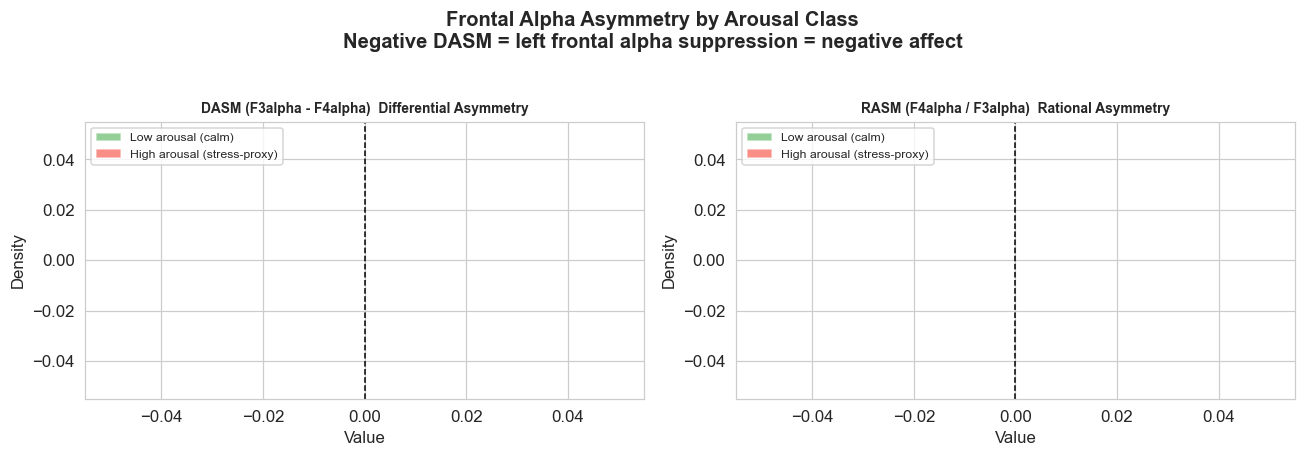

Saved: ..\results\plots\03_dreamer_exploration\frontal_asymmetry_by_arousal.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat, title in zip(axes,
    ['dasm','rasm'],
    ['DASM (F3alpha - F4alpha)  Differential Asymmetry',
     'RASM (F4alpha / F3alpha)  Rational Asymmetry']):
    for bl, color, name in [(0,'#4CAF50','Low arousal (calm)'),
                             (1,'#F44336','High arousal (stress-proxy)')]:
        vals = df_alpha.loc[df_alpha['arousal_binary']==bl, feat].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.axvline(0, color='black', linestyle='--', lw=1)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Frontal Alpha Asymmetry by Arousal Class\n'
             'Negative DASM = left frontal alpha suppression = negative affect',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'frontal_asymmetry_by_arousal.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 7. EEG Band Power Heatmap

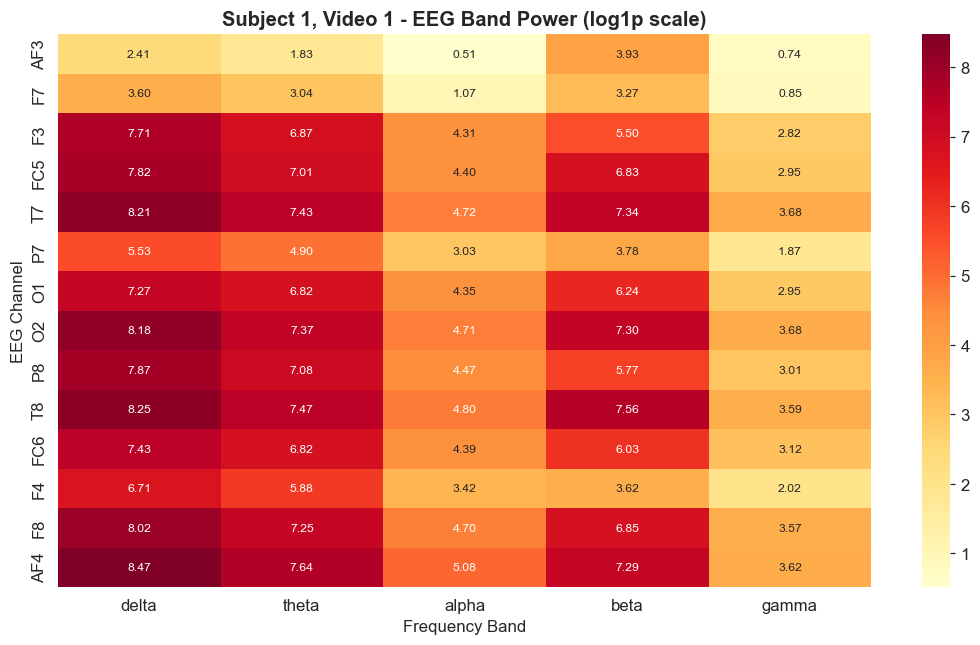

Saved: ..\results\plots\03_dreamer_exploration\S1_eeg_band_power_heatmap.png


In [11]:
band_matrix = np.zeros((N_EEG_CH, len(BANDS)))
for i in range(N_EEG_CH):
    for j, (band, (fmin, fmax)) in enumerate(BANDS.items()):
        band_matrix[i, j] = band_power(s0_stim[:, i], FS_EEG, fmin, fmax)
df_bands = pd.DataFrame(band_matrix, index=EEG_CHANNELS, columns=list(BANDS.keys()))
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(np.log1p(df_bands), annot=True, fmt='.2f',
            cmap='YlOrRd', ax=ax, annot_kws={'size': 8})
ax.set_title('Subject 1, Video 1 - EEG Band Power (log1p scale)', fontweight='bold')
ax.set_xlabel('Frequency Band')
ax.set_ylabel('EEG Channel')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'S1_eeg_band_power_heatmap.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 8. Stimulus Duration & Class Balance

=== EEG Stimulus Duration (seconds) ===
count    414.00
mean     207.11
std       89.81
min       67.00
25%      145.00
50%      188.00
75%      256.00
max      394.00
Name: duration_s, dtype: float64

=== Arousal Class Balance per Subject ===
            low_arousal  high_arousal
subject_id                           
1                    18             0
2                    18             0
3                    18             0
4                    18             0
5                    18             0
6                    18             0
7                    18             0
8                    18             0
9                    18             0
10                   18             0
11                   18             0
12                   18             0
13                   18             0
14                   18             0
15                   18             0
16                   18             0
17                   18             0
18                   18           

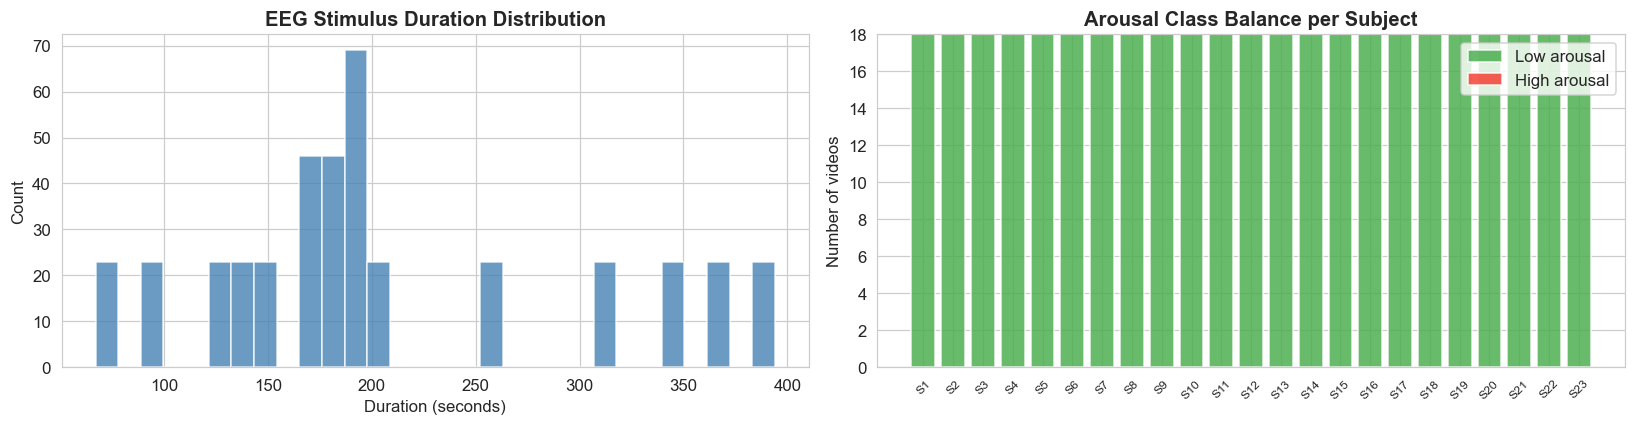

Saved: ..\results\plots\03_dreamer_exploration\duration_and_class_balance.png
Saved: ..\results\output_data\dreamer_stimulus_durations.csv


In [13]:
# Stimulus durations
dur_rows = []
for sid in range(N_SUBJECTS):
    for vid, stim in enumerate(data_all[sid]['EEG']['stimuli']):
        arr = np.array(stim)
        n   = arr.shape[0] if arr.shape[0] > arr.shape[1] else arr.shape[1]
        dur_rows.append({'subject_id': sid+1, 'video_id': vid+1, 'duration_s': n/FS_EEG})
df_dur = pd.DataFrame(dur_rows)
print('=== EEG Stimulus Duration (seconds) ===')
print(df_dur['duration_s'].describe().round(2))

# Class balance per subject — safe version
balance_raw = df_ratings.groupby(['subject_id','arousal_binary']).size().unstack(fill_value=0)

# Ensure both columns exist even if one class is missing
for col in [0, 1]:
    if col not in balance_raw.columns:
        balance_raw[col] = 0
balance_raw = balance_raw[[0, 1]]
balance_raw.columns = ['low_arousal', 'high_arousal']

print('\n=== Arousal Class Balance per Subject ===')
print(balance_raw.to_string())
print(f'\nUnique arousal_binary values in df_ratings: {sorted(df_ratings["arousal_binary"].unique())}')
print(f'Total high arousal : {(df_ratings["arousal_binary"]==1).sum()}')
print(f'Total low arousal  : {(df_ratings["arousal_binary"]==0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(df_dur['duration_s'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('EEG Stimulus Duration Distribution', fontweight='bold')

x = np.arange(len(balance_raw))
axes[1].bar(x, balance_raw['low_arousal'],  label='Low arousal',  color='#4CAF50', alpha=0.85)
axes[1].bar(x, balance_raw['high_arousal'], bottom=balance_raw['low_arousal'],
            label='High arousal', color='#F44336', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'S{s}' for s in balance_raw.index], rotation=45, fontsize=8)
axes[1].set_ylabel('Number of videos')
axes[1].set_title('Arousal Class Balance per Subject', fontweight='bold')
axes[1].legend()

plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'duration_and_class_balance.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')

p = os.path.join(OUTPUT_DATA_DIR, 'dreamer_stimulus_durations.csv')
df_dur.to_csv(p, index=False)
print(f'Saved: {p}')

## 9. Data Quality Check

In [14]:
print('=== DREAMER Data Quality Check ===')
quality_log = {'subjects': {}}
for sid in range(N_SUBJECTS):
    issues = []
    for vid, stim in enumerate(data_all[sid]['EEG']['stimuli']):
        arr = np.array(stim, dtype=float)
        if np.isnan(arr).any(): issues.append(f'vid{vid+1}:NaN')
        if np.isinf(arr).any(): issues.append(f'vid{vid+1}:Inf')
    status = 'OK' if not issues else str(issues)
    print(f'  S{sid+1:2d}: {status}')
    quality_log['subjects'][f'S{sid+1}'] = status
nan_r = df_ratings[['valence','arousal','dominance']].isna().sum().to_dict()
print(f'\nMissing ratings: {nan_r}')
quality_log['missing_ratings'] = nan_r
p = os.path.join(LOGS_DIR, 'dreamer_data_quality.json')
with open(p,'w') as f: json.dump(quality_log, f, indent=2)
print(f'Saved: {p}')


=== DREAMER Data Quality Check ===
  S 1: OK
  S 2: OK
  S 3: OK
  S 4: OK
  S 5: OK
  S 6: OK
  S 7: OK
  S 8: OK
  S 9: OK
  S10: OK
  S11: OK
  S12: OK
  S13: OK
  S14: OK
  S15: OK
  S16: OK
  S17: OK
  S18: OK
  S19: OK
  S20: OK
  S21: OK
  S22: OK
  S23: OK

Missing ratings: {'valence': 414, 'arousal': 414, 'dominance': 414}
Saved: ..\results\logs\dreamer_data_quality.json


## 10. Summary Log

In [15]:
arousal_dist = {str(k): int(v) for k,v in
                df_ratings['arousal_binary'].value_counts().sort_index().items()}
summary = {
    'notebook'            : '03_dreamer_exploration',
    'timestamp'           : datetime.now().isoformat(),
    'dreamer_path'        : DREAMER_PATH,
    'n_subjects'          : N_SUBJECTS,
    'n_videos_per_subject': N_VIDEOS,
    'total_recordings'    : int(len(df_ratings)),
    'eeg': {'fs_hz': FS_EEG, 'n_channels': N_EEG_CH, 'channels': EEG_CHANNELS,
            'f3_idx': F3_IDX, 'f4_idx': F4_IDX},
    'ecg': {'fs_hz': FS_ECG, 'n_channels': N_ECG_CH},
    'frequency_bands'     : {k: list(v) for k,v in BANDS.items()},
    'binarization'        : {'threshold': AROUSAL_THRESHOLD,
                             'rule': f'arousal > {AROUSAL_THRESHOLD} -> high(1) else low(0)',
                             'class_counts': arousal_dist},
    'features_planned'    : ['band_power_per_channel (delta/theta/alpha/beta/gamma)',
                             'DASM (F3_alpha - F4_alpha)',
                             'RASM (F4_alpha / F3_alpha)',
                             'statistical moments per band (mean, var, skew, kurt)'],
    'next'                : '04_dreamer_preprocessing.ipynb'
}
p = os.path.join(LOGS_DIR, '03_dreamer_exploration_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)
print('=' * 60)
print('DREAMER EXPLORATION COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


DREAMER EXPLORATION COMPLETE
{
  "notebook": "03_dreamer_exploration",
  "timestamp": "2026-05-09T16:38:44.083597",
  "dreamer_path": "C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat",
  "n_subjects": 23,
  "n_videos_per_subject": 18,
  "total_recordings": 414,
  "eeg": {
    "fs_hz": 128,
    "n_channels": 14,
    "channels": [
      "AF3",
      "F7",
      "F3",
      "FC5",
      "T7",
      "P7",
      "O1",
      "O2",
      "P8",
      "T8",
      "FC6",
      "F4",
      "F8",
      "AF4"
    ],
    "f3_idx": 2,
    "f4_idx": 11
  },
  "ecg": {
    "fs_hz": 256,
    "n_channels": 2
  },
  "frequency_bands": {
    "delta": [
      1,
      4
    ],
    "theta": [
      4,
      8
    ],
    "alpha": [
      8,
      13
    ],
    "beta": [
      13,
      30
    ],
    "gamma": [
      30,
      45
    ]
  },
  "binarization": {
    "threshold": 3,
    "rule": "arousal > 3 -> high(1) else low(0)",
    "class_counts": {
      "0": 414
    }
  },
 